In [1]:
# Library Imports
import numpy             as np 
import pandas            as pd 
import matplotlib.pyplot as plt
import seaborn           as sns
import random            as rnd
import os

from   sklearn.ensemble  import RandomForestClassifier

# Input directory "walk"
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

train_data  = pd.read_csv('/kaggle/input/titanic/train.csv')
test_data   = pd.read_csv('/kaggle/input/titanic/test.csv')
gender_data = pd.read_csv('/kaggle/input/titanic/gender_submission.csv')

dfg = gender_data
df  = train_data
dft = test_data

df.info()

/kaggle/input/titanic/train.csv
/kaggle/input/titanic/test.csv
/kaggle/input/titanic/gender_submission.csv
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [2]:
df.describe()
df.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [3]:
dft.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [4]:
nanAge = df[df['Age'].isnull()]
nanAge.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,177.000000,177.000000,177.000000,0.0,177.000000,177.000000,177.000000
mean,435.581921,0.293785,2.598870,NaN,0.564972,0.180791,22.158567
std,250.552901,0.456787,0.763216,NaN,1.626316,0.534145,31.874608
min,6.000000,0.000000,1.000000,NaN,0.000000,0.000000,0.000000
25%,230.000000,0.000000,3.000000,NaN,0.000000,0.000000,7.750000
50%,452.000000,0.000000,3.000000,NaN,0.000000,0.000000,8.050000
75%,634.000000,1.000000,3.000000,NaN,0.000000,0.000000,24.150000
max,889.000000,1.000000,3.000000,NaN,8.000000,2.000000,227.525000


<Axes: xlabel='Pclass'>

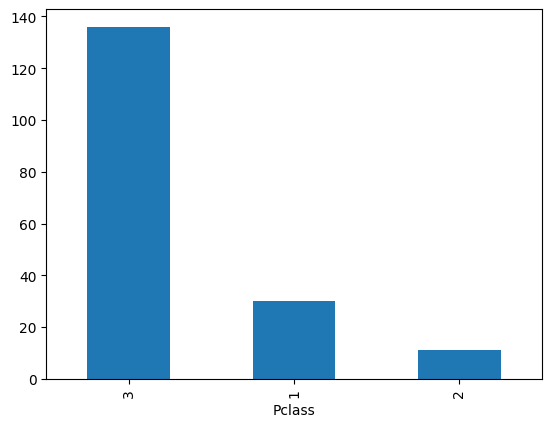

In [5]:
df[df['Age'].isnull()]['Pclass'].value_counts().plot(kind='bar')

In [6]:
# Embarked filled with mode
df['Embarked'] = df['Embarked'].mode()[0]


In [7]:
# identify correlation between survived and missing age value and cabin
# Quantify missing cabin data
copy = df[df.isna().any(axis=1)].copy()
df_nan = copy

df_nan['Cabin_Missing'] = df_nan['Cabin'].isna().astype(int)

df = pd.merge(df,df_nan[['PassengerId','Cabin_Missing']],
             on = 'PassengerId',
             how = 'left')

# All passengers with cabins have NaN values
df['Cabin_Missing'] = df['Cabin_Missing'].fillna(0).astype(int)

df_nan = copy

# Quantify missing age data

df_nan['Age_Missing'] = df_nan['Age'].isna().astype(int)

# Merge missing age data with df
df = pd.merge(df,df_nan[['PassengerId','Age_Missing']],
             on = 'PassengerId',
             how = 'left')
df['Age_Missing'] = df['Age_Missing'].fillna(0).astype(int)

# sibsp 
df['Sex']   = df['Sex'].map({'male':0,'female':1})
df['Group'] = df['Parch'] + df['SibSp']

In [8]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_Missing,Age_Missing
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208,0.771044,0.198653
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429,0.420397,0.399210
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400,1.000000,0.000000
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200,1.000000,0.000000
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000,1.000000,0.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200,1.000000,1.000000


In [9]:
df.nunique()

PassengerId      891
Survived           2
Pclass             3
Name             891
Sex                2
Age               88
SibSp              7
Parch              7
Ticket           681
Fare             248
Cabin            147
Embarked           1
Cabin_Missing      2
Age_Missing        2
dtype: int64

### Considerations:

- create categories/bins for Pclass, Survival, Embarked, Honorifics, sibsp/parch, age

- missing data in age, cabin, and embarked. Take mean and standard deviation to implement to missing data in category bands

- Age and Cabin have many missing values. 

In [10]:
# # Create Subset of Pclass data

# # Syntax: dataFrame[condition]['ColumnName']
# # Get mean value of Age column for Na values
# # round float value and convert to integer

# train_data['Age'] = round(train_data['Age'].fillna(train_data['Age'].mean()).astype(int), 2)

# test_data['Age'] = round(test_data['Age'].fillna(test_data['Age'].mean()).astype(int), 2)

# train_data.shape

In [11]:
mask = (df['Age'] < 1) & (df['Survived'])
df[mask]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Cabin_Missing,Age_Missing
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S,1,0
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S,0,0
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,S,1,0
644,645,1,3,"Baclini, Miss. Eugenie",female,0.75,2,1,2666,19.2583,NaN,S,1,0
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S,1,0
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,S,1,0
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S,1,0


In [12]:
age_freq = df['Age'].value_counts().sort_index(ascending = True)

for age, freq in age_freq.items():
    print(f" {age} : {freq}")

 0.42 : 1
 0.67 : 1
 0.75 : 2
 0.83 : 2
 0.92 : 1
 1.0 : 7
 2.0 : 10
 3.0 : 6
 4.0 : 10
 5.0 : 4
 6.0 : 3
 7.0 : 3
 8.0 : 4
 9.0 : 8
 10.0 : 2
 11.0 : 4
 12.0 : 1
 13.0 : 2
 14.0 : 6
 14.5 : 1
 15.0 : 5
 16.0 : 17
 17.0 : 13
 18.0 : 26
 19.0 : 25
 20.0 : 15
 20.5 : 1
 21.0 : 24
 22.0 : 27
 23.0 : 15
 23.5 : 1
 24.0 : 30
 24.5 : 1
 25.0 : 23
 26.0 : 18
 27.0 : 18
 28.0 : 25
 28.5 : 2
 29.0 : 20
 30.0 : 25
 30.5 : 2
 31.0 : 17
 32.0 : 18
 32.5 : 2
 33.0 : 15
 34.0 : 15
 34.5 : 1
 35.0 : 18
 36.0 : 22
 36.5 : 1
 37.0 : 6
 38.0 : 11
 39.0 : 14
 40.0 : 13
 40.5 : 2
 41.0 : 6
 42.0 : 13
 43.0 : 5
 44.0 : 9
 45.0 : 12
 45.5 : 2
 46.0 : 3
 47.0 : 9
 48.0 : 9
 49.0 : 6
 50.0 : 10
 51.0 : 7
 52.0 : 6
 53.0 : 1
 54.0 : 8
 55.0 : 2
 55.5 : 1
 56.0 : 4
 57.0 : 2
 58.0 : 5
 59.0 : 2
 60.0 : 4
 61.0 : 3
 62.0 : 4
 63.0 : 2
 64.0 : 2
 65.0 : 3
 66.0 : 1
 70.0 : 2
 70.5 : 1
 71.0 : 2
 74.0 : 1
 80.0 : 1


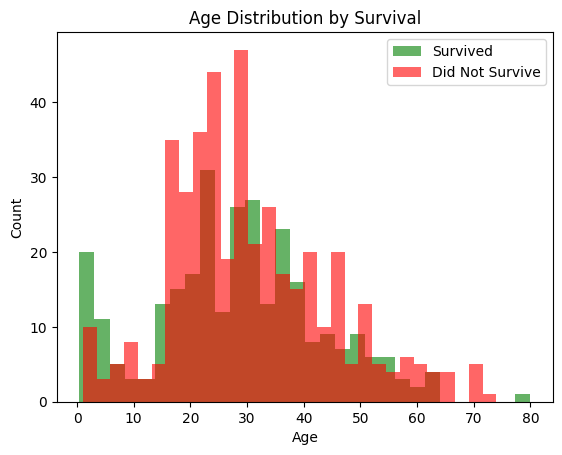

In [13]:
df[df['Survived'] == 1]['Age'].plot(kind='hist', alpha=0.6, label='Survived', bins=30, color='green')
df[df['Survived'] == 0]['Age'].plot(kind='hist', alpha=0.6, label='Did Not Survive', bins=30, color='red')

plt.title('Age Distribution by Survival')
plt.xlabel('Age')
plt.ylabel('Count')
plt.legend()
plt.show()

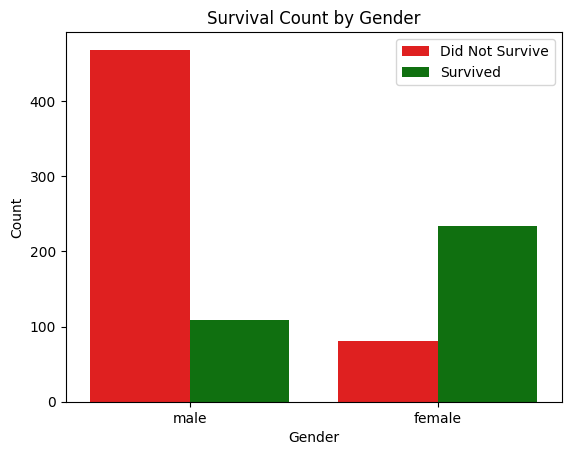

In [14]:
sns.countplot(data=df, x='Sex', hue='Survived', palette=['red', 'green'])

plt.title('Survival Count by Gender')
plt.xlabel('Gender')
plt.ylabel('Count')
plt.legend(labels=['Did Not Survive', 'Survived'])
plt.show()

# Feature Pivoting
 - Compare relationships between features by applying pivot table
 - Pclass
 - Survived
 - Age
 - Group
 - Embarked
   

### Pclass vs Survived

### Sex vs. Survived

In [15]:
train_data['group'] = train_data['SibSp'] + train_data['Parch']
train_data.drop(columns=['SibSp','Parch'], inplace=True)

test_data['group'] = test_data['SibSp'] + test_data['Parch']
test_data.drop(columns=['SibSp','Parch'], inplace=True)

train_data.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,group
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,211536,13.00,NaN,S,0
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,112053,30.00,B42,S,0
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,W./C. 6607,23.45,NaN,S,3
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,111369,30.00,C148,S,0
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,370376,7.75,NaN,S,0


In [16]:
# train_data['Sex'] = train_data['Sex'].map({'male':0, 'female':1}) # MAP sex to binary

train_data['Sex'] = train_data['Sex'].map({'male':0, 'female':1})
test_data['Sex'] = test_data['Sex'].map({'male':0, 'female':1})

train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,group
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,PC 17599,71.2833,C85,S,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,373450,8.0500,NaN,S,0


In [17]:
train_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,Ticket,Fare,Cabin,Embarked,group
0,1,0,3,"Braund, Mr. Owen Harris",0,22.0,A/5 21171,7.2500,NaN,S,1
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",1,38.0,PC 17599,71.2833,C85,S,1
2,3,1,3,"Heikkinen, Miss. Laina",1,26.0,STON/O2. 3101282,7.9250,NaN,S,0
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",1,35.0,113803,53.1000,C123,S,1
4,5,0,3,"Allen, Mr. William Henry",0,35.0,373450,8.0500,NaN,S,0


In [18]:
# Create correlation matrix to get numeric relationships between features

correlation_matrix = train_data[['Pclass','Survived','Sex','Age','Fare','group']].corr()
print(correlation_matrix)

            Pclass  Survived       Sex       Age      Fare     group
Pclass    1.000000 -0.338481 -0.131900 -0.369226 -0.549500  0.065997
Survived -0.338481  1.000000  0.543351 -0.077221  0.257307  0.016639
Sex      -0.131900  0.543351  1.000000 -0.093254  0.182333  0.200988
Age      -0.369226 -0.077221 -0.093254  1.000000  0.096067 -0.301914
Fare     -0.549500  0.257307  0.182333  0.096067  1.000000  0.217138
group     0.065997  0.016639  0.200988 -0.301914  0.217138  1.000000


#### Pclass x Survived: Negative correlation
- Passenger class directly affected survival rate

#### Survived x Sex: Strongly positive correlation
- females had higher chance of survival

#### Pclass x Sex: Weak negative correlation
- slightly skewed toward males, but not by much

#### Pclass x Age: Strong negative correlation
- younger passengers were in Pclass 3 and older were
  in Pclass1

#### Survived x Age: Weak negative correlation
- Age had negligible impact on survival

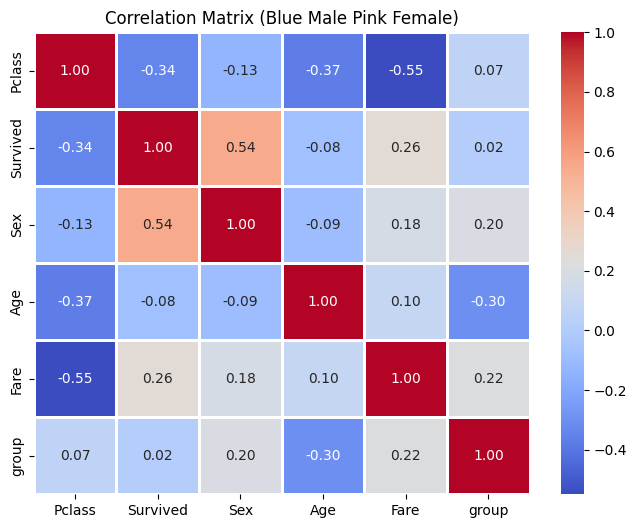

In [19]:
# Correlation heat map
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, 
            annot=True, cmap='coolwarm', fmt='.2f',
           linewidths=1)
plt.title('Correlation Matrix (Blue Male Pink Female)')
plt.show()

In [20]:
# checking Na/Nan values, we see 177 Na in 'Age', and 687 Na in 'Cabin'
train_data.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
Ticket           0
Fare             0
Cabin          687
Embarked         0
group            0
dtype: int64

In [21]:
mean_fare_by_pclass = test_data.groupby('Pclass')['Fare'].transform('mean')
print(mean_fare_by_pclass)

0      12.459678
1      12.459678
2      22.202104
3      12.459678
4      12.459678
         ...    
413    12.459678
414    94.280297
415    12.459678
416    12.459678
417    12.459678
Name: Fare, Length: 418, dtype: float64


In [22]:
test_data['Fare'] = test_data['Fare'].fillna(mean_fare_by_pclass)
test_data.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
Ticket           0
Fare             0
Cabin          327
Embarked         0
group            0
dtype: int64

In [23]:
# String splitter for names and honorifics
# result = "".join([v.strip(",()[].\"'") for v in x.split(" ")])
# print(result)

In [24]:
df.isna().sum()

PassengerId        0
Survived           0
Pclass             0
Name               0
Sex                0
Age              177
SibSp              0
Parch              0
Ticket             0
Fare               0
Cabin            687
Embarked           0
Cabin_Missing      0
Age_Missing        0
dtype: int64

# for Model training
### Use 'X' as standard for independent variables
### Use y as standard for target / dependent variable

In [25]:
# # tutorial code with raw data

# from sklearn.ensemble import RandomForestClassifier

# y = train_data["Survived"]

# features = ["Pclass", "Sex", "Age", "Group","Fare"]
# X = pd.get_dummies(df[features])
# X_test = pd.get_dummies(dft[features])

# model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
# model.fit(X, y)
# predictions = model.predict(X_test)

# output = pd.DataFrame({'PassengerId': test_data.PassengerId, 'Survived': predictions})
# output.to_csv('submission.csv', index=False)
# print("Your submission was successfully saved!")
